In [1]:
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt

import xarray as xr
import pandas as pd
import geopandas as gpd
from glob import glob

import time

from cartopy.crs import Geodetic, Stereographic, PlateCarree
from cartopy.feature import LAND, COASTLINE

import warnings
warnings.simplefilter("ignore")

# Set Parameters

In [2]:
# Parameters
year = 2024
site = "BP03"

isPapermill = False

In [4]:
# Set the basic mapping parameters
suptitle_size = 20
title_size = 16
map_size = (16, 8)
extent = (2.5, 27.5, 52, 62)
lon_mid = np.mean(extent[:2])
lat_mid = np.mean(extent[2:])
map_projection = Stereographic(
    central_longitude=lon_mid, central_latitude=lat_mid,
    )
def basemap(ax):
    ax.set_extent(extent, PlateCarree())
    ax.add_feature(LAND)
    ax.add_feature(COASTLINE)
    ax.gridlines(draw_labels=["left", "bottom"], y_inline=False,)
    return ax

In [7]:
# Paths
folder_path = "/gxfs_work/geomar/smomw597/2025_copepods/output/"
trajectory_path = Path(folder_path, f"Trajectories/{year}/")
sample_points_path = Path(folder_path, "SamplePoints/SamplePoints.shp")
voronoi_polygons_path = Path(folder_path, "SamplePoints/VoronoiPolygons.shp")
output_path = Path(folder_path, f"VoronoiConnectivity/")

In [8]:
# Load the samplepoints and the voronoi polygons
gdf_sample_points = gpd.read_file(sample_points_path)
gdf_voronoi_polygons = gpd.read_file(voronoi_polygons_path).to_crs(Geodetic())

# Get site index, if the site name was given and the other way around
if type(site) == str:
    site_name = site
    site_index = gdf_sample_points.where(gdf_sample_points.SampleID==site).first_valid_index()
elif type(site) == int:
    site_name = gdf_sample_points.loc[site].SampleID
    site_index = site

# set starting site to 'active'
gdf_sample_points.SampleKind.loc[site_index] = "active" 
print(site_name, site_index)

BP03 23


In [7]:
# Read and prepare the trajectory file
trajectory_file = sorted(trajectory_path.glob(f"*{site_name}*"))[0]
ds_trajectories = xr.open_zarr(trajectory_file)
# Make a mask that masks all days with an age under 10 days
trajectories_age_mask = ds_trajectories.age_sec.chunk(chunks=[2000,2784]).compute() > 10*24*60*60
# Only get the positions and mask
ds_trajectories = ds_trajectories.get(["lat","lon"]).where(trajectories_age_mask, drop=True)

In [7]:
# Take the pitions and build a pandas dataframe out of it, making it as small as possible
df_trajectories = ds_trajectories.to_dataframe().reset_index().dropna()
# removing the xr Datset, as it is not longer needed but big in the memory
del ds_trajectories

In [8]:
# Build a Gepandas Gedataframe frm the dataframe and delete the df afterwards t safe n memry
gdf_trajectories = gpd.GeoDataFrame(geometry=gpd.points_from_xy(df_trajectories.lon, df_trajectories.lat, crs=Geodetic()))
del df_trajectories

In [9]:
# Check, in which polygon each particle is
gdf_trajectories = (gpd
    .sjoin(left_df=gdf_trajectories, right_df=gdf_voronoi_polygons, how="left", rsuffix="polygon")
    .drop(columns=['index', 'index_polygon0', 'SampleKind'])
)

<Axes: xlabel='PolygonID'>

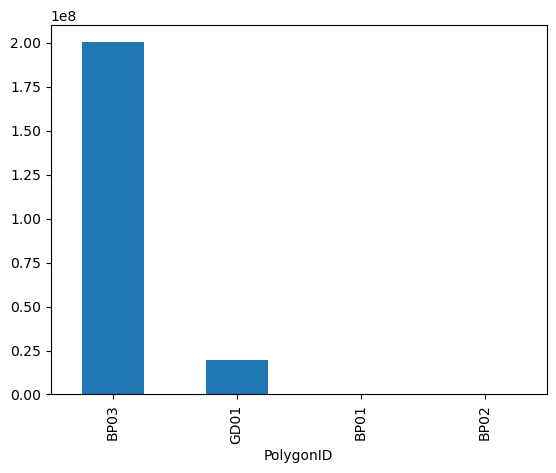

In [10]:
# Count the particles per polygon
polygon_count = gdf_trajectories.PolygonID.value_counts()
polygon_count.plot(kind="bar")

In [ ]:
# Write the counts per polygon into a connectivity matrix
for n in range(10):
    # For the unlikely case, that multiple notebooks try to write in the same file, 
    # a mechanism to delay the writing process was employed
    try:
        # If the connectivity matrix for the given year already exists, thake that
        try:
            connectivity_matrix = pd.read_csv(Path(output_path,f"connectivitymatrix_voronoi_{year}.csv"), index_col=0)
            print('Updated file')
        # Else make a new one
        except:
            connectivity_matrix = pd.DataFrame(
                np.zeros([len(gdf_sample_points.SampleID),len(gdf_sample_points.SampleID)]),
                index=gdf_sample_points.SampleID,
                columns=gdf_voronoi_polygons.PolygonID,
            )
            print('Created a new file')
        # Then write the count values for the start site ('site_name") into the respective cell of the polygon ('polygon_name')
        for polygon_name, count in polygon_count.items():
            connectivity_matrix.loc[site_name].loc[polygon_name] = count
        connectivity_matrix.to_csv(Path(output_path, f"connectivitymatrix_voronoi_{year}.csv"))
        break
    except:
        print('n')
        print(np.random.rand()*n**2)
        time.sleep(np.random.rand()*n**2)
connectivity_matrix

Updated file


,KB03,SW08,BE01,GD01,IU07,LL17,FI01,SK02,WH02,KG01,...,EG01,EG02,SR03,WG01,WG02,BP03,BB23,BB36,GB96,HR21
SampleID,,,,,,,,,,,,,,,,,,,,,
KB03,148810913.0,22418499.0,44855843.0,0.0,0.0,0.0,0.0,0.0,0.0,2614508.0,...,0.0,0.0,0.0,0.0,0.0,0.0,30209.0,0.0,0.0,975141.0
SW08,18062079.0,167453939.0,2808145.0,0.0,0.0,0.0,0.0,0.0,0.0,5168527.0,...,0.0,0.0,0.0,0.0,0.0,0.0,275451.0,2348.0,0.0,25781663.0
BE01,50897202.0,16048977.0,150359134.0,0.0,0.0,0.0,0.0,0.0,0.0,2124608.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1511.0,114.0,0.0,298751.0
GD01,0.0,0.0,0.0,219397242.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,506531.0,0.0,0.0,0.0,0.0
IU07,0.0,0.0,0.0,0.0,175982337.0,34577244.0,7540651.0,0.0,0.0,0.0,...,0.0,1771707.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
LL17,0.0,0.0,0.0,0.0,37312894.0,137609272.0,993367.0,0.0,0.0,0.0,...,836.0,40672980.0,0.0,0.0,3324893.0,0.0,0.0,0.0,0.0,0.0
FI01,0.0,0.0,0.0,0.0,979563.0,4591462.0,200496374.0,0.0,0.0,0.0,...,0.0,1666.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SK02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,203502831.0,273385.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
WH02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2604153.0,216494246.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


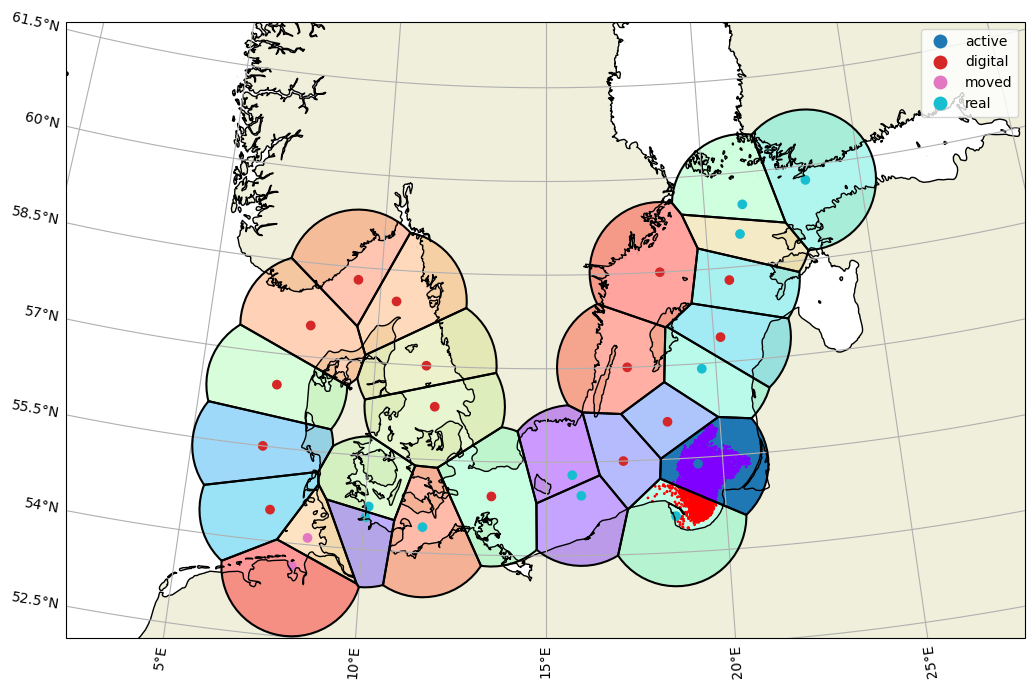

In [ ]:
fig = plt.figure(figsize=map_size)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
gdf_voronoi_polygons.to_crs(map_projection).plot(ax=ax_map,alpha=0.4, column="PolygonID", cmap="rainbow")
gdf_voronoi_polygons.where(gdf_voronoi_polygons.PolygonID==site_name).to_crs(map_projection).plot(ax=ax_map, legend=True)
gdf_trajectories[::24*400].to_crs(map_projection).plot(ax=ax_map, column="PolygonID", cmap="rainbow", s=1)
gdf_voronoi_polygons.boundary.to_crs(map_projection).plot(ax=ax_map, color="k",)
gdf_sample_points.plot(ax=ax_map, column="SampleKind", legend=True)
plt.show()

In [35]:
gdf_sorted = gdf_sample_points.sort_values("order")#.geometry.x

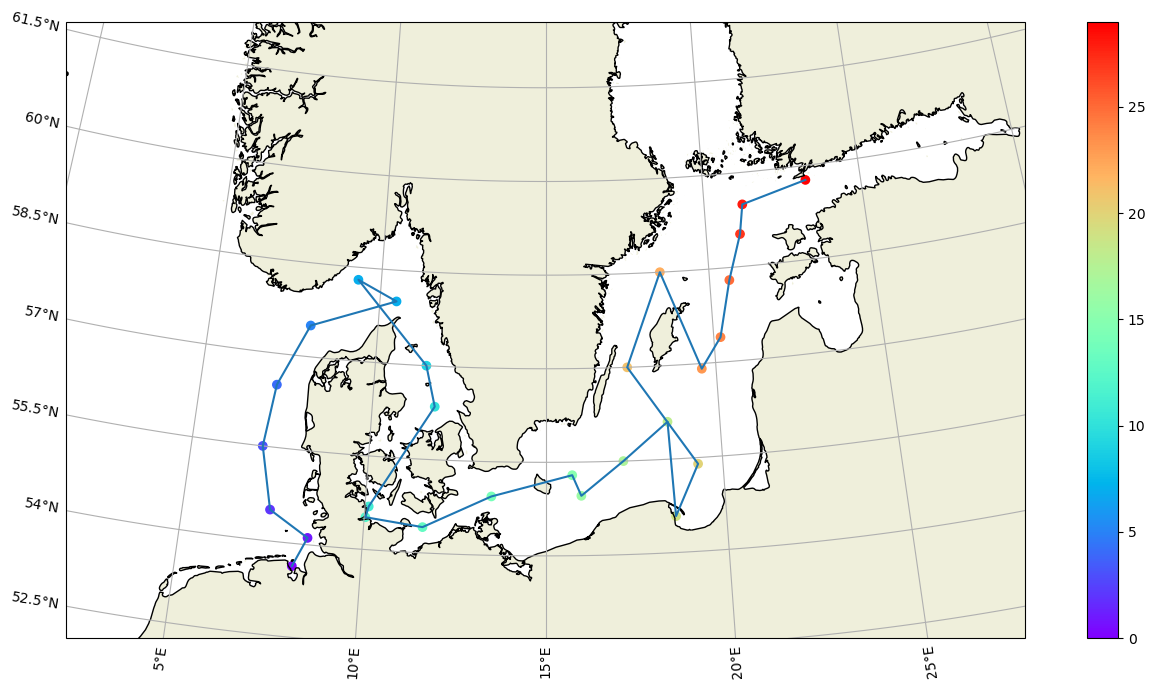

In [ ]:
gdf_sorted = gdf_sample_points.sort_values("order")#.geometry.x
fig = plt.figure(figsize=map_size)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
gdf_sample_points.plot(ax=ax_map, column="order", cmap='rainbow', legend=True)
ax_map.plot(gdf_sorted.geometry.x, gdf_sorted.geometry.y)
plt.show()